In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/insuranceData.txt', delimiter='|')

C:\Users\MihretT\AppData\Local\Temp\ipykernel_10164\3312333056.py:1: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/insuranceData.txt', delimiter='|')


In [3]:
# check columns
print(df.columns)

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')


In [4]:
# Preview the random 5 rows
print(df.sample(5))

        UnderwrittenCoverID  PolicyID     TransactionMonth  IsVATRegistered  \
535811                89908      6963  2015-04-01 00:00:00            False   
93126                  2930       374  2014-08-01 00:00:00            False   
625250                75838      5860  2015-03-01 00:00:00            False   
562276                66664      5324  2014-11-01 00:00:00            False   
751465               107317      8227  2015-06-01 00:00:00            False   

       Citizenship   LegalType Title Language           Bank      AccountType  \
535811              Individual    Mr  English            NaN  Current account   
93126               Individual    Mr  English      ABSA Bank  Current account   
625250              Individual    Mr  English  Standard Bank  Current account   
562276              Individual    Mr  English            NaN  Current account   
751465              Individual   Mrs  English   Capitec Bank  Savings account   

        ...                           

In [5]:
# Check the shape (rows, columns)
print("Shape:", df.shape)

Shape: (1000098, 52)


In [6]:
# View basic summary statistics
print(df.describe(include='all'))

        UnderwrittenCoverID      PolicyID     TransactionMonth  \
count          1.000098e+06  1.000098e+06              1000098   
unique                  NaN           NaN                   23   
top                     NaN           NaN  2015-08-01 00:00:00   
freq                    NaN           NaN               106747   
mean           1.048175e+05  7.956682e+03                  NaN   
std            6.329371e+04  5.290039e+03                  NaN   
min            1.000000e+00  1.400000e+01                  NaN   
25%            5.514300e+04  4.500000e+03                  NaN   
50%            9.408300e+04  7.071000e+03                  NaN   
75%            1.391900e+05  1.107700e+04                  NaN   
max            3.011750e+05  2.324600e+04                  NaN   

       IsVATRegistered Citizenship   LegalType    Title Language  \
count          1000098     1000098     1000098  1000098  1000098   
unique               2           4           6        5        1   
top

In [7]:
# parse TransactionMonth to datetime format
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

In [8]:
# check datetime format
print(df['TransactionMonth'].dtype)

datetime64[ns]


In [ ]:
# copy the original data
df_copy = df.copy()

In [10]:
# Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values:\n", missing)

Missing values:
 NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
WrittenOff                  641901
Converted                   641901
Rebuilt                     641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
mmcode                         552
VehicleType                    552
make                           552
VehicleIntroDate               552
NumberOfDoors                  552
bodytype                       552
kilowatts                      552
cubiccapacity                  552
Cylinders                      552
Model                          552
CapitalOutstanding               2
dtype: int64


Data Cleaning: Handling Missing Value

In [11]:
# Drop column with 100% missing
df.drop(columns=['NumberOfVehiclesInFleet'], inplace=True)

In [12]:
# Drop column with 100% missing
df.drop(columns=['CustomValueEstimate'], inplace=True)

In [13]:
df.shape

(1000098, 50)

In [14]:
# 2. Drop high-missing vehicle condition fields
vehicle_condition_cols = ['WrittenOff', 'Converted', 'Rebuilt', 'CrossBorder']
df.drop(columns = vehicle_condition_cols, inplace=True)

In [15]:
df.shape

(1000098, 46)

In [16]:
pd.set_option('display.max_columns', None)
df.sample(10)

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
369157,71519,5810,2015-01-01,False,,Individual,Mr,English,First National Bank,Savings account,Not specified,Not specified,South Africa,North West,458,Transvaal (all except Pretoria),Transvaal North,Mobility - Motor,28524090.0,Heavy Commercial,2008,IVECO,50 C15V 15 F/C P/V,4.0,2798.0,107.0,P/V,5.0,7/2004,Yes,No,0,More than 6 months,7500.00,Monthly,2.8124,No excess,Cleaning and Removal of Accident Debris,Cleaning and Removal of Accident Debris,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,2.467018,0.0
996851,143388,12669,2015-06-01,False,ZA,Individual,Mr,English,Standard Bank,Current account,Not specified,Not specified,South Africa,KwaZulu-Natal,4092,Natal (Durban),Durban,Mobility - Motor,60058400.0,Passenger Vehicle,2013,TOYOTA,QUANTUM 2.5 D-4D 14 SEAT,4.0,2494.0,75.0,B/S,4.0,3/2005,Yes,Yes,0.0,More than 6 months,100000.00,Monthly,50.0000,No excess,Accidental Death,Accidental Death,Accidental Death,Optional Extended Covers,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,0.000000,0.0
111527,150630,13692,2015-05-01,False,,Individual,Mr,English,ABSA Bank,Savings account,Not specified,Not specified,South Africa,KwaZulu-Natal,4004,Natal (Durban),Durban,Mobility - Motor,60058415.0,Passenger Vehicle,2008,TOYOTA,QUANTUM 2.7 SESFIKILE 14s,4.0,2694.0,111.0,B/S,4.0,11/2007,Yes,Yes,0.0,More than 6 months,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,21.929825,0.0
384996,114537,8418,2015-05-01,False,,Individual,Mr,English,First National Bank,Savings account,Not specified,Not specified,South Africa,KwaZulu-Natal,4091,Natal (Durban),Durban,Mobility - Motor,7512100.0,Passenger Vehicle,2009,C.A.M,INYATHI,4.0,2237.0,76.0,B/S,4.0,2006/07/01 12:00:00 AM,Yes,No,0,More than 6 months,100000.00,Monthly,50.0000,No excess,Accidental Death,Accidental Death,Accidental Death,Optional Extended Covers,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,43.859649,0.0
335073,92236,7237,2014-11-01,False,,Individual,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,2093,Johannesburg,Johannesburg,Mobility - Motor,60058418.0,Passenger Vehicle,2010,TOYOTA,QUANTUM 2.7 SESFIKILE 15s,4.0,2694.0,111.0,B/S,4.0,10/2010,Yes,No,0,More than 6 months,5000000.00,Monthly,2.2044,No excess,Passenger Liability,Passenger Liability,Comprehensive - Taxi,Motor Comprehensive,Mobility Commercial Cover: Monthly,Commercial,IFRS Constant,1.933684,0.0
350622,73424,5991,2015-05-01,False,,Individual,Mr,English,First National Bank,Savings account,Not specified,Not specified,South Africa,Gauteng,2000,Johannesburg,Johannesburg,Mobility - Motor,10031150.0,Passenger Vehicle,2012,CHEVROLET,SONIC 1.3D LS 5DR,4.0,1248.0,74.0,H/B,5.0,11/2011,Yes,No,0,More than 6 months,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
428498,108363,8244,2015-02-01,False,,Individual,Mr,English,First National Bank,Savings account,Not specified,Not specified,South Africa,KwaZulu-Natal,4037,Natal (Durban),Durban,Mobility - Motor,60056987.0,Passenger Vehicle,2007,TOYOTA,HiACE SIYAYA,4.0,2237.0,75.0,B/S,4.0,8/2001,Yes,No,0,More than 6 months,500000.00,Monthly,242.3716,No excess,Third Party,Third Party,Comprehensi

Univariate Analysis

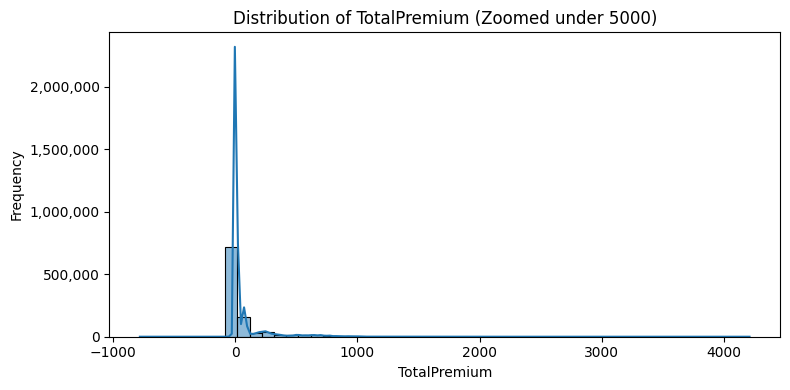

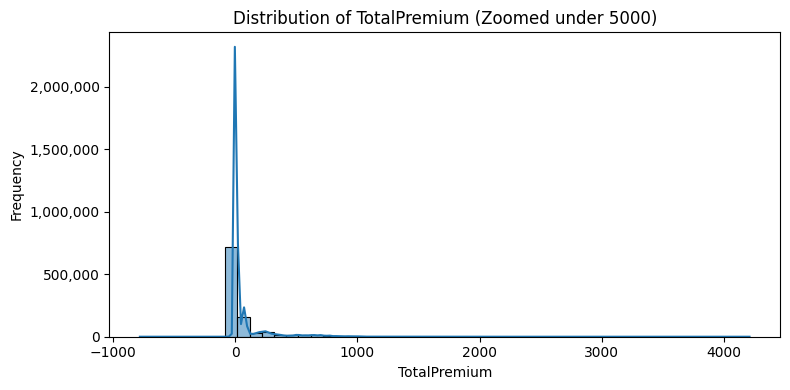

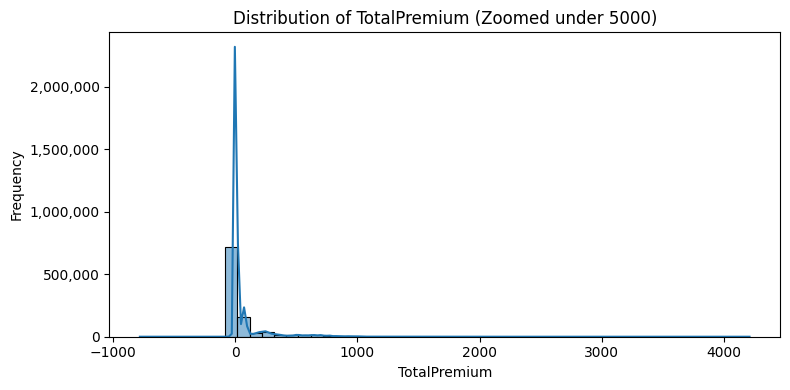

In [21]:
# Plot histograms for numeric variables

import matplotlib.ticker as mtick

num_cols = ['TotalPremium', 'TotalClaims', 'CalculatedPremiumPerTerm']

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[df['TotalPremium'] < 5000]['TotalPremium'], bins=50, kde=True)
    plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.title('Distribution of TotalPremium (Zoomed under 5000)')
    plt.xlabel('TotalPremium')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

C:\Users\MihretT\AppData\Local\Temp\ipykernel_10164\3989327489.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_province.index, y=loss_by_province.values, palette='coolwarm')


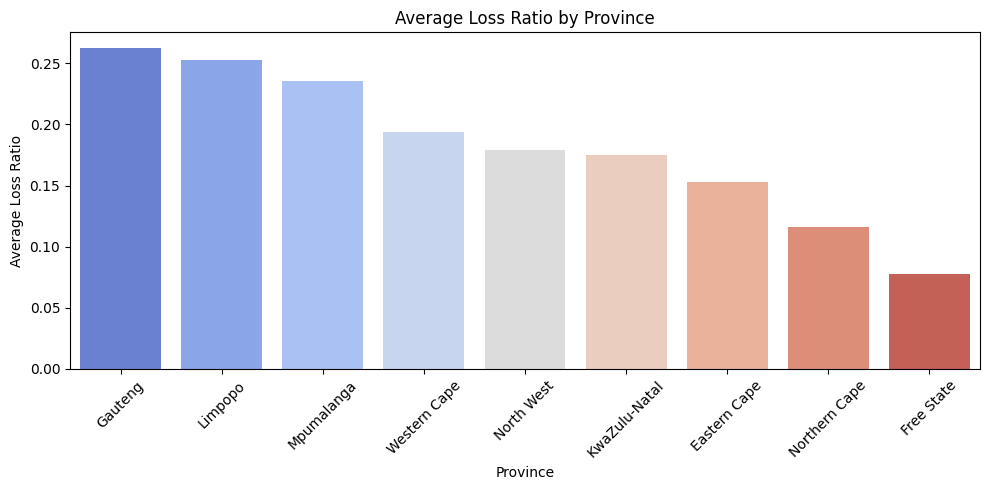

In [22]:
# Create Loss Ratio column
df['LossRatio'] = df.apply(lambda row: row['TotalClaims'] / row['TotalPremium'] if row['TotalPremium'] > 0 else 0, axis=1)

# Group and plot
loss_by_province = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=loss_by_province.index, y=loss_by_province.values, palette='coolwarm')
plt.title('Average Loss Ratio by Province')
plt.ylabel('Average Loss Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\MihretT\AppData\Local\Temp\ipykernel_10164\1173697806.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_gender.index, y=loss_by_gender.values, palette='viridis')


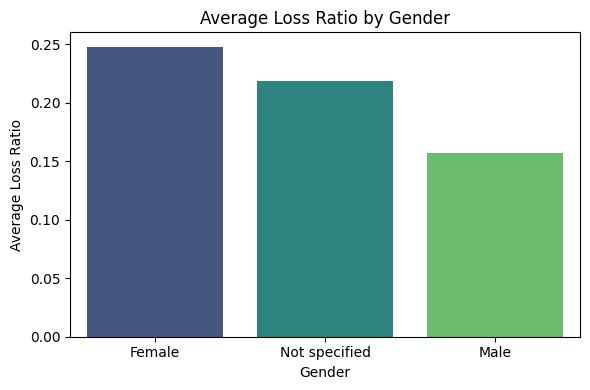

In [23]:
# Group by Gender and calculate average Loss Ratio
loss_by_gender = df.groupby('Gender')['LossRatio'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=loss_by_gender.index, y=loss_by_gender.values, palette='viridis')
plt.title('Average Loss Ratio by Gender')
plt.ylabel('Average Loss Ratio')
plt.xlabel('Gender')
plt.tight_layout()
plt.show()

C:\Users\MihretT\AppData\Local\Temp\ipykernel_10164\3355661784.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loss_by_vehicle.index, y=loss_by_vehicle.values, palette='magma')


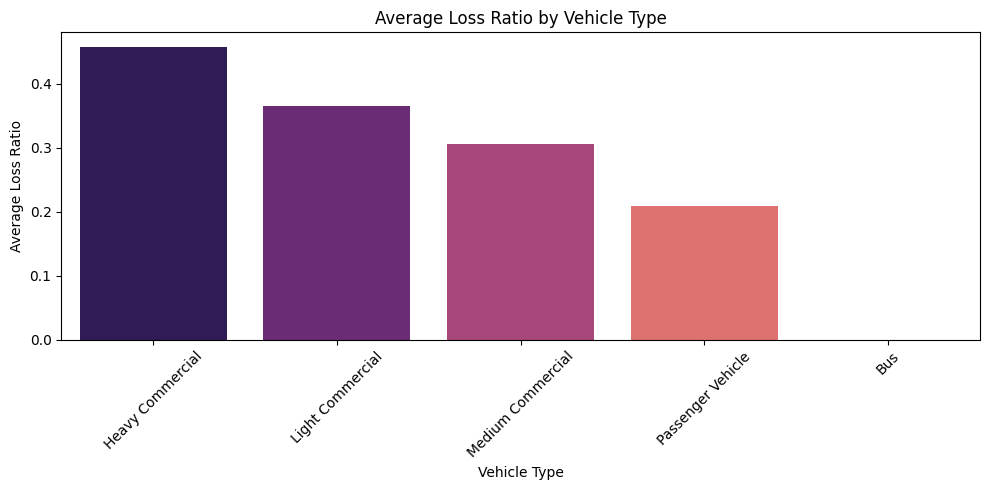

In [24]:
# Group by VehicleType and calculate average Loss Ratio
loss_by_vehicle = df.groupby('VehicleType')['LossRatio'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=loss_by_vehicle.index, y=loss_by_vehicle.values, palette='magma')
plt.title('Average Loss Ratio by Vehicle Type')
plt.ylabel('Average Loss Ratio')
plt.xlabel('Vehicle Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

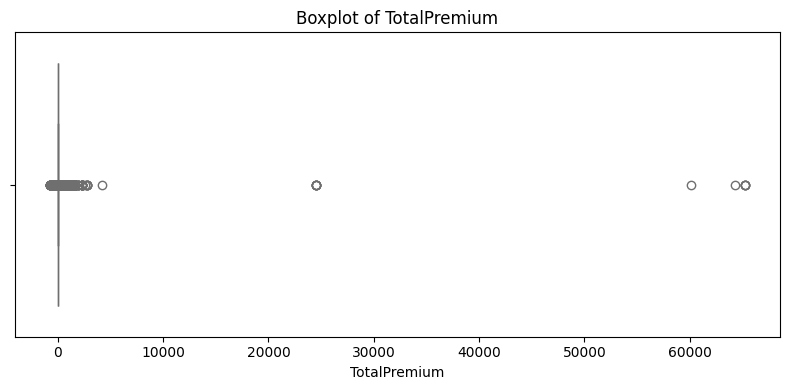

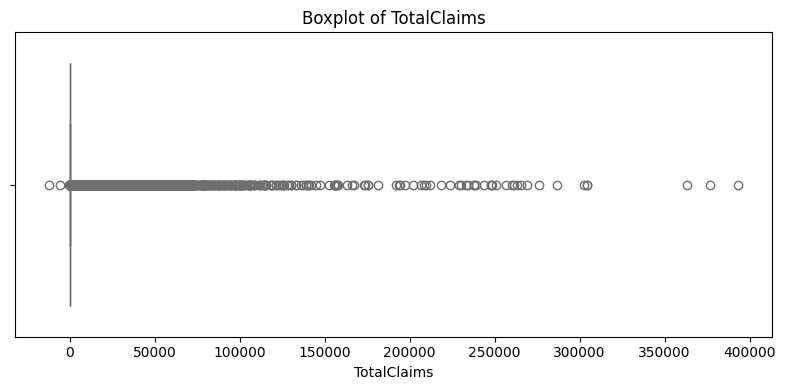

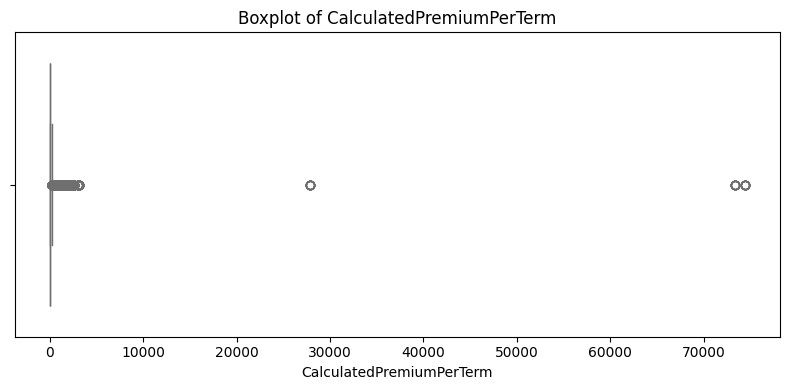

In [ ]:
# Outlier Detection using Boxplots
num_cols = ['TotalPremium', 'TotalClaims', 'CalculatedPremiumPerTerm']

for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

Bivariate or Multivariate Analysis

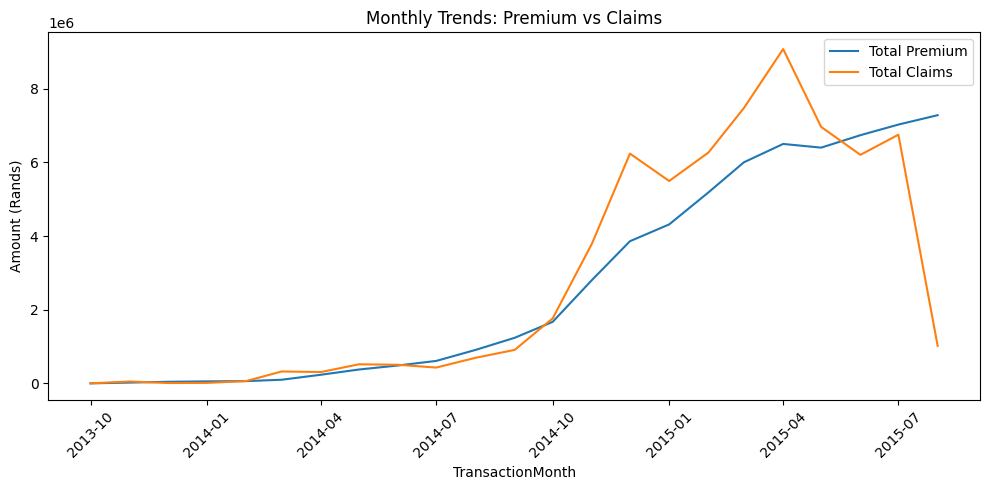

In [26]:
# Monthly Aggregated Trends
monthly_agg = df.groupby('TransactionMonth')[['TotalPremium', 'TotalClaims']].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_agg, x='TransactionMonth', y='TotalPremium', label='Total Premium')
sns.lineplot(data=monthly_agg, x='TransactionMonth', y='TotalClaims', label='Total Claims')
plt.title("Monthly Trends: Premium vs Claims")
plt.ylabel("Amount (Rands)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

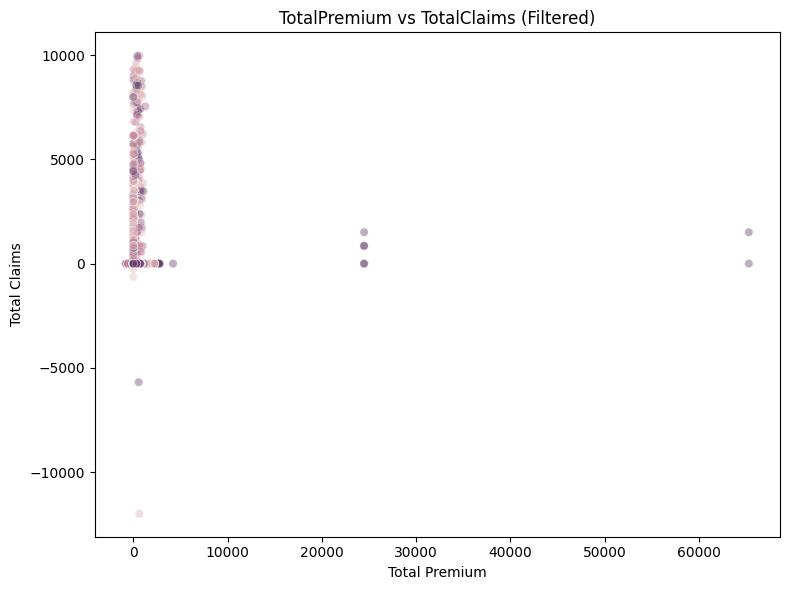

In [27]:
# Scatter Plot: TotalPremium vs TotalClaims (as a function of PostalCode)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df[df['TotalClaims'] < 10000], x='TotalPremium', y='TotalClaims', hue='PostalCode', alpha=0.4, legend=False)
plt.title('TotalPremium vs TotalClaims (Filtered)')
plt.xlabel('Total Premium')
plt.ylabel('Total Claims')
plt.tight_layout()
plt.show()

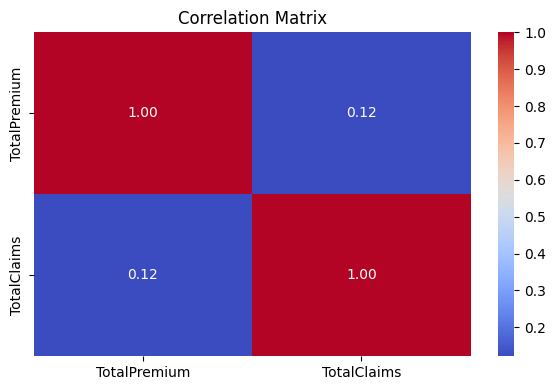

In [ ]:
# Correlation Matrix
corr = df[['TotalPremium', 'TotalClaims']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

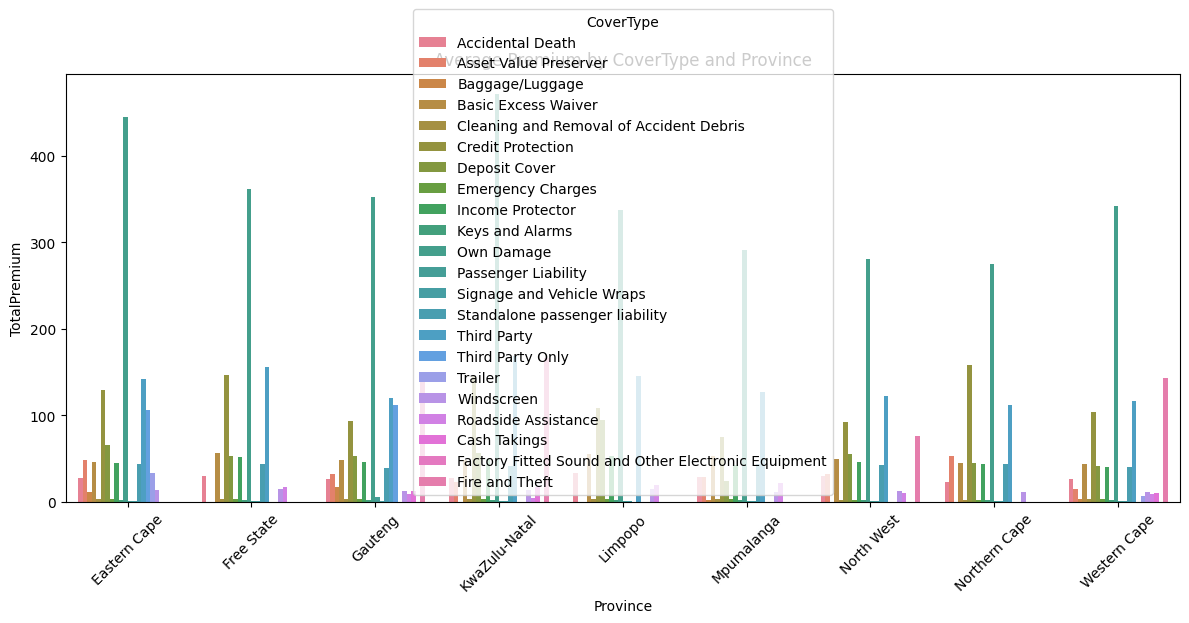

In [30]:
# Data Comparison: Trends Over Geography
geo_trend = df.groupby(['Province', 'CoverType'])['TotalPremium'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=geo_trend, x='Province', y='TotalPremium', hue='CoverType')
plt.title('Average Premium by CoverType and Province')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()